In [1]:
import numpy as np

In [2]:
import pandas as pd

In [3]:
import seaborn as sns

In [4]:
import matplotlib.pyplot as plt

In [5]:
sms_df = pd.read_csv(r"U:\ML\SMS SPAM CLASS\spam.csv", encoding="latin1")


In [6]:
sms_df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [7]:
sms_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [8]:
sms_df.drop(columns=["Unnamed: 2","Unnamed: 3","Unnamed: 4"],inplace=True)

In [9]:
sms_df.rename(columns={"v1":"output","v2":"msg"},inplace=True)

In [10]:
sms_df["output"].value_counts()

output
ham     4825
spam     747
Name: count, dtype: int64

In [11]:
from sklearn.preprocessing import LabelEncoder

In [12]:
le=LabelEncoder()
sms_df['output']=le.fit_transform(sms_df['output'])

In [13]:
sms_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   output  5572 non-null   int32 
 1   msg     5572 non-null   object
dtypes: int32(1), object(1)
memory usage: 65.4+ KB


In [14]:
sms_df.sample(5)

,output,msg
4755,0,Don't make life too stressfull.. Always find t...
313,0,"Hi the way I was with u 2day, is the normal wa..."
576,0,I'm tired of arguing with you about this week ...
1784,0,"Dont search love, let love find U. Thats why i..."
5221,0,"Jane babes not goin 2 wrk, feel ill after lst ..."


In [15]:
sms_df.isnull().sum()

output    0
msg       0
dtype: int64

In [16]:
sms_df.duplicated().sum()


403

In [17]:
sms_df=sms_df.drop_duplicates(keep='first')

In [18]:
sms_df.shape

(5169, 2)

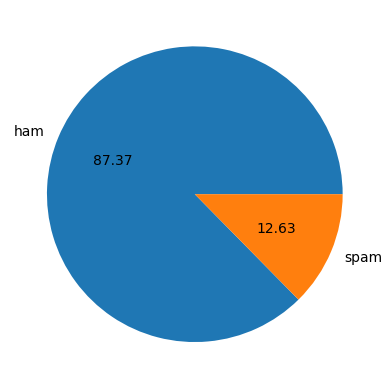

In [19]:
plt.pie(sms_df['output'].value_counts(),labels=['ham','spam'],autopct="%0.2f")
plt.show()

In [20]:
sms_df.head()


,output,msg
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [21]:
!pip install nltk


In [22]:
import nltk

In [23]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to C:\Users\Uzair
[nltk_data]     Ahmad/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [24]:
sms_df['no_char']=sms_df['msg'].apply(len)

In [25]:
sms_df.head()

,output,msg,no_char
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [26]:
sms_df['no_words'] = sms_df['msg'].apply(lambda x: len(x.split()))

In [27]:
sms_df.head()

,output,msg,no_char,no_words
0,0,"Go until jurong point, crazy.. Available only ...",111,20
1,0,Ok lar... Joking wif u oni...,29,6
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,28
3,0,U dun say so early hor... U c already then say...,49,11
4,0,"Nah I don't think he goes to usf, he lives aro...",61,13


In [28]:
import re

In [29]:
sms_df['no_sents']=sms_df['msg'].apply(lambda x: len(re.split(r'(?<=[.!?])\s+', x)))

In [30]:
sms_df.head()

,output,msg,no_char,no_words,no_sents
0,0,"Go until jurong point, crazy.. Available only ...",111,20,3
1,0,Ok lar... Joking wif u oni...,29,6,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,28,2
3,0,U dun say so early hor... U c already then say...,49,11,2
4,0,"Nah I don't think he goes to usf, he lives aro...",61,13,1


In [31]:
sms_df.rename(columns={"no_char":"no_chars"},inplace=True)

In [32]:
sms_df[['no_chars','no_words','no_sents']].describe()

,no_chars,no_words,no_sents
count,5169.000000,5169.000000,5169.000000
mean,78.977945,15.340685,2.096150
std,58.236293,11.068488,1.524009
min,2.000000,1.000000,1.000000
25%,36.000000,7.000000,1.000000
50%,60.000000,12.000000,2.000000
75%,117.000000,22.000000,3.000000
max,910.000000,171.000000,39.000000


In [33]:
#ham
sms_df[sms_df['output']==0][['no_chars','no_words','no_sents']].describe()

,no_chars,no_words,no_sents
count,4516.000000,4516.000000,4516.000000
mean,70.459256,14.134632,1.957263
std,56.358207,11.116240,1.465646
min,2.000000,1.000000,1.000000
25%,34.000000,7.000000,1.000000
50%,52.000000,11.000000,2.000000
75%,90.000000,18.000000,2.000000
max,910.000000,171.000000,39.000000


In [34]:
#spam
sms_df[sms_df['output']==1][['no_chars','no_words','no_sents']].describe()

,no_chars,no_words,no_sents
count,653.000000,653.000000,653.000000
mean,137.891271,23.681470,3.056662
std,30.137753,5.967672,1.573800
min,13.000000,2.000000,1.000000
25%,132.000000,22.000000,2.000000
50%,149.000000,25.000000,3.000000
75%,157.000000,28.000000,4.000000
max,224.000000,35.000000,9.000000


<Axes: xlabel='no_chars', ylabel='Count'>

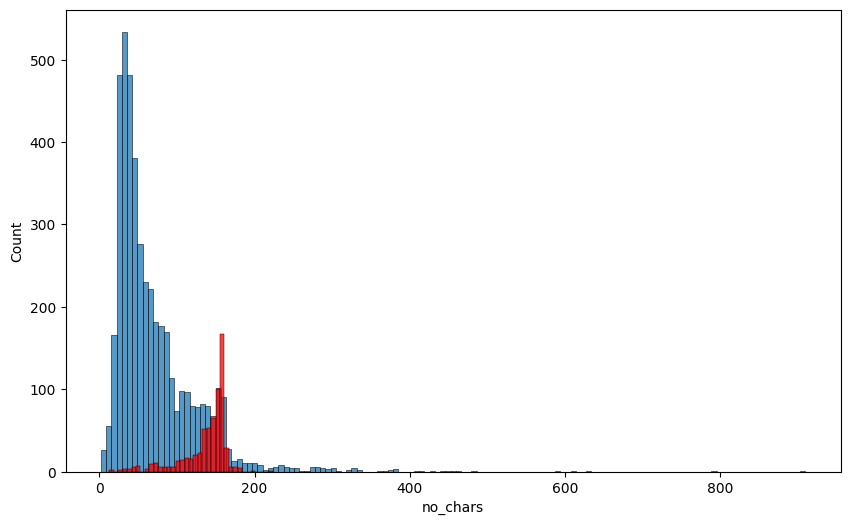

In [35]:
plt.figure(figsize=(10,6))
sns.histplot(sms_df[sms_df['output']==0]['no_chars'])
sns.histplot(sms_df[sms_df['output']==1]['no_chars'],color='red')

<Axes: xlabel='no_words', ylabel='Count'>

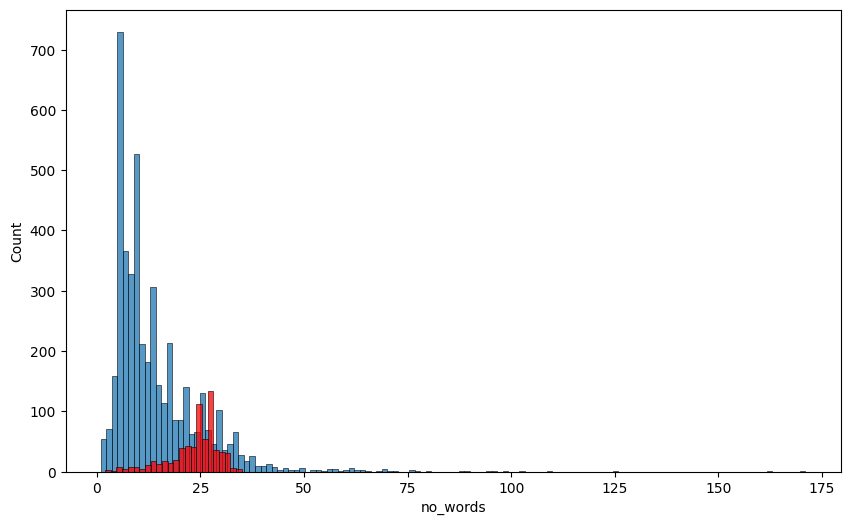

In [36]:
plt.figure(figsize=(10,6))
sns.histplot(sms_df[sms_df['output']==0]['no_words'])
sns.histplot(sms_df[sms_df['output']==1]['no_words'],color='red')

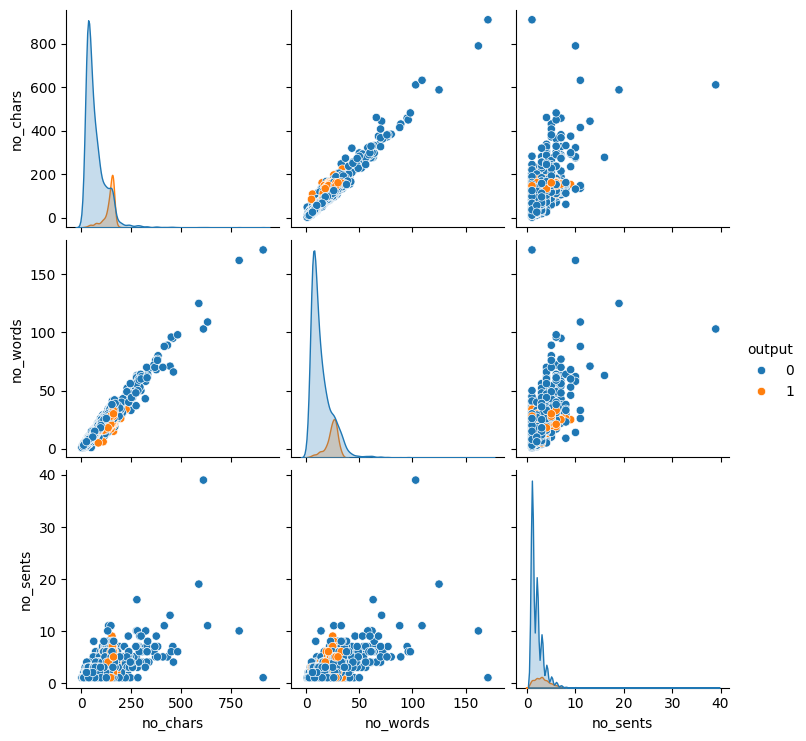

In [37]:
sns.pairplot(data=sms_df[['no_chars','no_words','no_sents','output']],hue='output')

In [38]:
corr_matrix=sms_df[['output','no_chars','no_words','no_sents']].corr()

<Axes: >

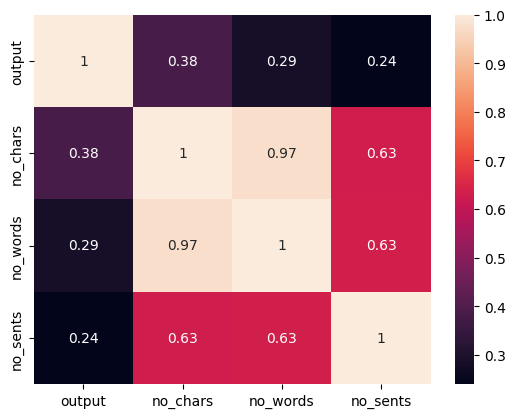

In [39]:
sns.heatmap(corr_matrix,annot=True)

In [40]:
import nltk
nltk.download('stopwords')


[nltk_data] Downloading package stopwords to C:\Users\Uzair
[nltk_data]     Ahmad/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [41]:
from nltk.corpus import stopwords
stopwords.words('English')

['i',
 'me',
 'my',
 'myself',
 'we',
 'our',
 'ours',
 'ourselves',
 'you',
 "you're",
 "you've",
 "you'll",
 "you'd",
 'your',
 'yours',
 'yourself',
 'yourselves',
 'he',
 'him',
 'his',
 'himself',
 'she',
 "she's",
 'her',
 'hers',
 'herself',
 'it',
 "it's",
 'its',
 'itself',
 'they',
 'them',
 'their',
 'theirs',
 'themselves',
 'what',
 'which',
 'who',
 'whom',
 'this',
 'that',
 "that'll",
 'these',
 'those',
 'am',
 'is',
 'are',
 'was',
 'were',
 'be',
 'been',
 'being',
 'have',
 'has',
 'had',
 'having',
 'do',
 'does',
 'did',
 'doing',
 'a',
 'an',
 'the',
 'and',
 'but',
 'if',
 'or',
 'because',
 'as',
 'until',
 'while',
 'of',
 'at',
 'by',
 'for',
 'with',
 'about',
 'against',
 'between',
 'into',
 'through',
 'during',
 'before',
 'after',
 'above',
 'below',
 'to',
 'from',
 'up',
 'down',
 'in',
 'out',
 'on',
 'off',
 'over',
 'under',
 'again',
 'further',
 'then',
 'once',
 'here',
 'there',
 'when',
 'where',
 'why',
 'how',
 'all',
 'any',
 'both',
 'each

In [42]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [43]:
from nltk.stem.porter import PorterStemmer
ps=PorterStemmer()

In [44]:
def transform_text(text):
    text=text.lower()
    text=text.split()

    y=[]
    for i in text:
        if i.isalnum():
            y.append(i)

    text=y[:]
    y.clear()

    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)

    text=y[:]
    y.clear()

    for i in text:
        y.append(ps.stem(i))
        
    return " ".join(y)

In [45]:
transform_text('dancing')

'danc'

In [46]:
sms_df['transformed_msg']=sms_df['msg'].apply(transform_text)

In [47]:
sms_df.head()

,output,msg,no_chars,no_words,no_sents,transformed_msg
0,0,"Go until jurong point, crazy.. Available only ...",111,20,3,go jurong avail bugi n great world la e cine g...
1,0,Ok lar... Joking wif u oni...,29,6,2,ok joke wif u
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,28,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,11,2,u dun say earli u c alreadi
4,0,"Nah I don't think he goes to usf, he lives aro...",61,13,1,nah think goe live around though


In [48]:
!pip install wordcloud


In [49]:
from wordcloud import WordCloud

wc = WordCloud(width=1000, height=1000, min_font_size=10, background_color='white')

spam_wc = wc.generate(sms_df[sms_df['output'] == 1]['transformed_msg'].str.cat(sep=" "))


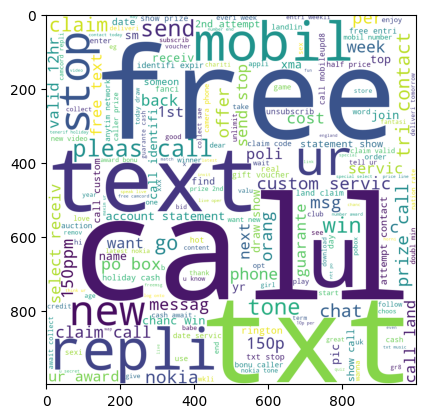

In [50]:
plt.imshow(spam_wc)

In [51]:
wc = WordCloud(width=1000, height=1000, min_font_size=10, background_color='white')
ham_wc = wc.generate(sms_df[sms_df['output'] == 0]['transformed_msg'].str.cat(sep=" "))

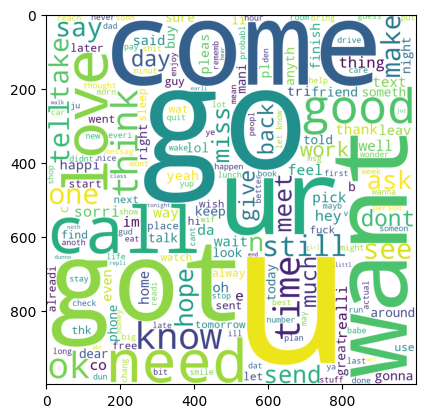

In [52]:
plt.imshow(ham_wc)

In [53]:
spam_words=[]
for msg in sms_df[sms_df['output']==1]['transformed_msg'].tolist():
    for word in msg.split():
        spam_words.append(word)

    

In [54]:
len(spam_words)

8176

In [55]:
from collections import Counter
spam_word_df=pd.DataFrame(Counter(spam_words).most_common(30))

In [56]:
spam_word_df.rename(columns={0:'word',1:"count"},inplace=True)

In [57]:
spam_word_df

,word,count
0,call,310
1,free,157
2,2,151
3,txt,122
4,ur,119
5,text,112
6,mobil,103
7,repli,100
8,u,96
9,claim,91


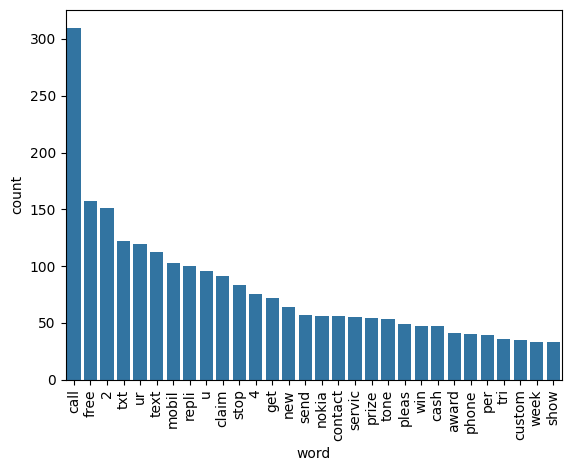

In [58]:
sns.barplot(x=spam_word_df['word'], y=spam_word_df['count'])
plt.xticks(rotation=90)
plt.show()

In [59]:
ham_words=[]
for msg in sms_df[sms_df['output']==0]['transformed_msg'].tolist():
    for word in msg.split():
        ham_words.append(word)


In [60]:
len(ham_words)

27382

In [61]:
ham_word_df=pd.DataFrame(Counter(ham_words).most_common(30),columns=['word','count'])

In [62]:
ham_word_df.head()

,word,count
0,u,794
1,go,379
2,get,339
3,2,272
4,come,251


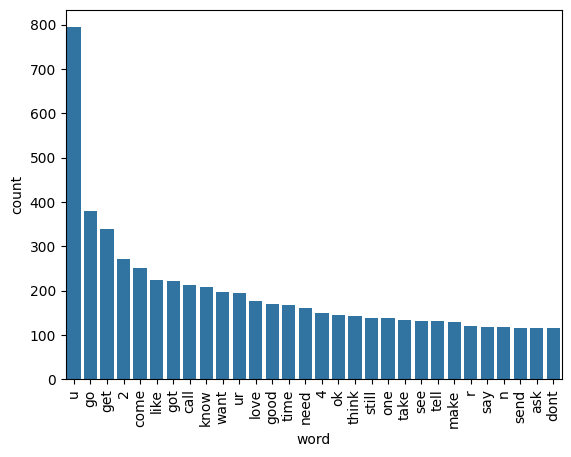

In [63]:
sns.barplot(x=ham_word_df['word'], y=ham_word_df['count'])
plt.xticks(rotation=90)
plt.show()

In [64]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv=CountVectorizer()
x=cv.fit_transform(sms_df['transformed_msg']).toarray()

In [65]:
x.shape

(5169, 5643)

In [66]:
tf=TfidfVectorizer(max_features=3300)
x=tf.fit_transform(sms_df['transformed_msg']).toarray()

In [67]:
y=sms_df['output'].values

In [68]:
y

array([0, 0, 1, ..., 0, 0, 0])

In [69]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=2)


In [70]:
xtrain.shape,xtest.shape,ytrain.shape,ytest.shape

((4135, 3300), (1034, 3300), (4135,), (1034,))

In [71]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB



In [72]:
from sklearn.metrics import precision_score,confusion_matrix,accuracy_score

In [73]:
gnb=GaussianNB()
gnb.fit(xtrain,ytrain)

GaussianNB()

In [74]:
yprdt=gnb.predict(xtest)

In [75]:
print(precision_score(ytest,yprdt))
print(accuracy_score(ytest,yprdt))
print(confusion_matrix(ytest,yprdt))

0.37623762376237624
0.7940038684719536
[[707 189]
 [ 24 114]]


In [76]:
mnb=MultinomialNB()
mnb.fit(xtrain,ytrain)
yprdt1=mnb.predict(xtest)

In [77]:
print(precision_score(ytest,yprdt1))
print(accuracy_score(ytest,yprdt1))
print(confusion_matrix(ytest,yprdt1))

1.0
0.9632495164410058
[[896   0]
 [ 38 100]]


In [78]:
bnb=BernoulliNB()
bnb.fit(xtrain,ytrain)

BernoulliNB()

In [79]:
yprdt2=bnb.predict(xtest)

In [80]:
print(precision_score(ytest,yprdt2))
print(accuracy_score(ytest,yprdt2))
print(confusion_matrix(ytest,yprdt2))

0.9747899159663865
0.9758220502901354
[[893   3]
 [ 22 116]]


In [81]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import BernoulliNB
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier


In [82]:
lr=LogisticRegression()
sv=SVC(kernel="sigmoid",gamma=1.0)
kn=KNeighborsClassifier()
bnb=BernoulliNB()
mnb=MultinomialNB()
dt=DecisionTreeClassifier(max_depth=5)
rf=RandomForestClassifier(n_estimators=50,random_state=2)
ab=AdaBoostClassifier(n_estimators=50,random_state=2)
bc=BaggingClassifier(n_estimators=50,random_state=2)
et=ExtraTreesClassifier(n_estimators=50,random_state=2)
gb=GradientBoostingClassifier(n_estimators=50,random_state=2)


In [83]:
clfs={
    "LR":lr,
    "SVC":sv,
    "KN":kn,
    "BNB":bnb,
    "MNB":mnb,
    "DTC":dt,
    "RandomF":rf,
    "AdaBoost":ab,
    "BaggingC":bc,
    "ETC":et,
    "GBC":gb
}

In [84]:
def train_classifier(clfs,xtrain,ytrain,xtest,ytest):
    clfs.fit(xtrain,ytrain)
    ypred=clfs.predict(xtest)
    accuracy=accuracy_score(ytest,ypred)
    precision=precision_score(ytest,ypred)
    return accuracy,precision

In [85]:
train_classifier(mnb,xtrain,ytrain,xtest,ytest)

(0.9632495164410058, 1.0)

In [86]:
accuracy_scores=[]
precision_scores=[]
for name,clf in clfs.items():
    c_accuracy,c_precision=train_classifier(clf,xtrain,ytrain,xtest,ytest)
    print("For -",name)
    print("accuracy",c_accuracy)
    \
    print("precision",c_precision)
    accuracy_scores.append(c_accuracy)
    precision_scores.append(c_precision)

For - LR
accuracy 0.9410058027079303
precision 0.963855421686747
For - SVC
accuracy 0.9671179883945842
precision 0.9262295081967213
For - KN
accuracy 0.9032882011605415
precision 0.975
For - BNB
accuracy 0.9758220502901354
precision 0.9747899159663865
For - MNB
accuracy 0.9632495164410058
precision 1.0
For - DTC
accuracy 0.9342359767891683
precision 0.8125
For - RandomF
accuracy 0.971953578336557
precision 0.9739130434782609


U:\SOFTWARES\Anaconda\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


For - AdaBoost
accuracy 0.9555125725338491
precision 0.9107142857142857
For - BaggingC
accuracy 0.9555125725338491
precision 0.8538461538461538
For - ETC
accuracy 0.9748549323017408
precision 0.9745762711864406
For - GBC
accuracy 0.9458413926499033
precision 0.8867924528301887


In [87]:
performance_df=pd.DataFrame({"Algorithm":clfs.keys(),"Accuracy":accuracy_scores,"Precision":precision_scores}).sort_values("Precision",ascending=False)

In [88]:
performance_df


,Algorithm,Accuracy,Precision
4,MNB,0.963250,1.000000
2,KN,0.903288,0.975000
3,BNB,0.975822,0.974790
9,ETC,0.974855,0.974576
6,RandomF,0.971954,0.973913
0,LR,0.941006,0.963855
1,SVC,0.967118,0.926230
7,AdaBoost,0.955513,0.910714
10,GBC,0.945841,0.886792
8,BaggingC,0.955513,0.853846


In [89]:
pdf1=pd.melt(performance_df,id_vars="Algorithm")

In [90]:
pdf1

,Algorithm,variable,value
0,MNB,Accuracy,0.963250
1,KN,Accuracy,0.903288
2,BNB,Accuracy,0.975822
3,ETC,Accuracy,0.974855
4,RandomF,Accuracy,0.971954
5,LR,Accuracy,0.941006
6,SVC,Accuracy,0.967118
7,AdaBoost,Accuracy,0.955513
8,GBC,Accuracy,0.945841
9,BaggingC,Accuracy,0.955513


<function matplotlib.pyplot.show(close=None, block=None)>

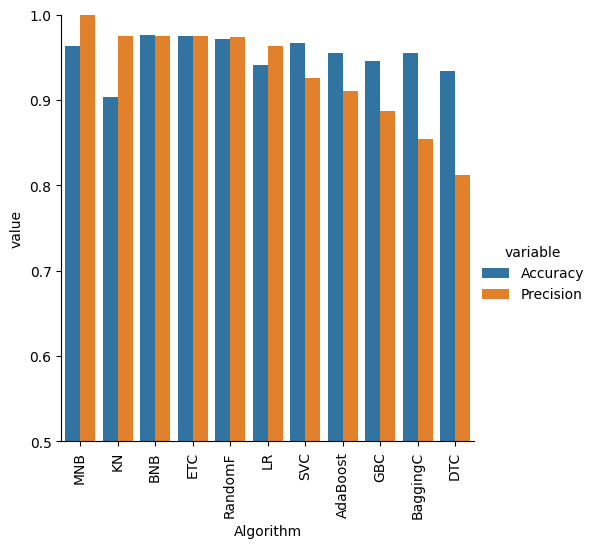

In [91]:
sns.catplot(data=pdf1,x="Algorithm",y="value",hue="variable",kind="bar")
plt.ylim(0.5,1.0)
plt.xticks(rotation=90)
plt.show

In [92]:
import pickle

In [93]:
pickle.dump(tf,open("vectorizer.pkl","wb"))

In [192]:
pickle.dump(mnb,open("mnb.pkl","wb"))